In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

DATA_DIR = Path.cwd().parent / "data"

TRAIN_IMAGES = DATA_DIR / "images" / "train"
TRAIN_LABELS = DATA_DIR / "labels" / "train"

print("Dataset:", DATA_DIR)
print("Training images:", TRAIN_IMAGES.exists())
print("Training labels:", TRAIN_LABELS.exists())

Dataset: /Users/priyansh/Downloads/airport-baggage-screening/data
Training images: True
Training labels: True


## Data Augmentation

Data augmentation increases the diversity of training samples by applying controlled transformations to X-ray images.

The objective is to improve model generalization and robustness without changing the semantic identity of prohibited objects.

Augmentations considered:
- Rotation
- Translation
- Scaling
- Horizontal flipping
- Brightness/contrast variation
- Mosaic augmentation

In [9]:
image_paths = sorted(TRAIN_IMAGES.glob("*.jpg"))

sample_path = image_paths[0]

image = cv2.imread(str(sample_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Sample:", sample_path.name)
print("Shape:", image.shape)

Sample: PID_xray_00000.jpg
Shape: (448, 620, 3)


In [10]:
def rotate_image(image, angle):
    height, width = image.shape[:2]

    center = (width // 2, height // 2)

    matrix = cv2.getRotationMatrix2D(
        center,
        angle,
        1.0
    )

    rotated = cv2.warpAffine(
        image,
        matrix,
        (width, height)
    )

    return rotated

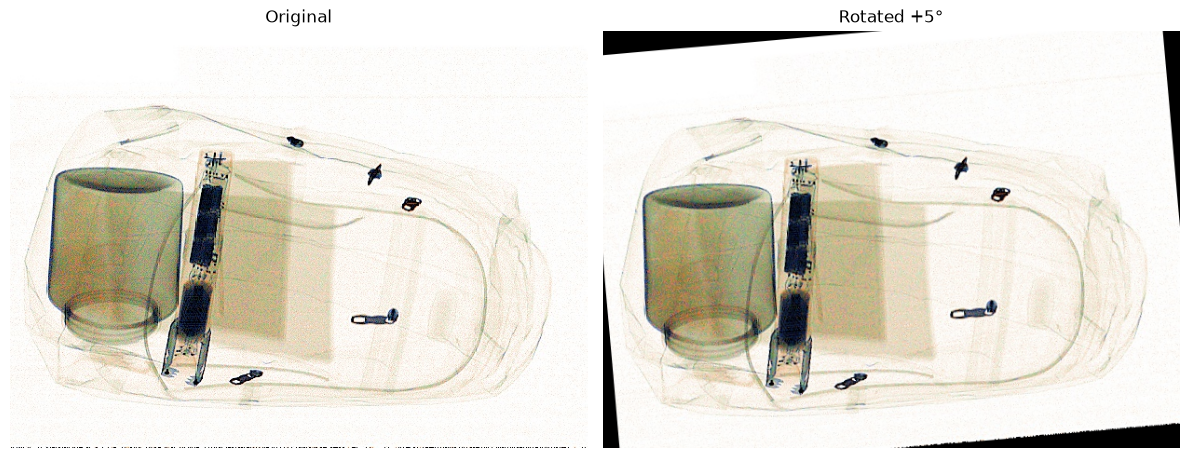

In [11]:
rotated = rotate_image(image, 5)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rotated)
plt.title("Rotated +5°")
plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
def adjust_brightness(image, factor=1.15):

    image_float = image.astype(np.float32)

    adjusted = image_float * factor

    adjusted = np.clip(
        adjusted,
        0,
        255
    ).astype(np.uint8)

    return adjusted

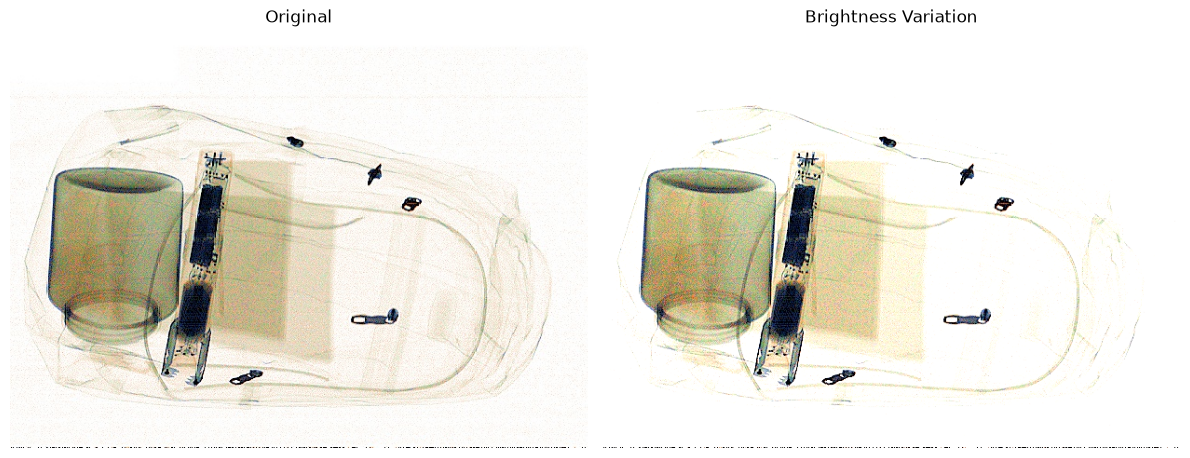

In [13]:
brighter = adjust_brightness(image, 1.15)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(brighter)
plt.title("Brightness Variation")
plt.axis("off")

plt.tight_layout()
plt.show()

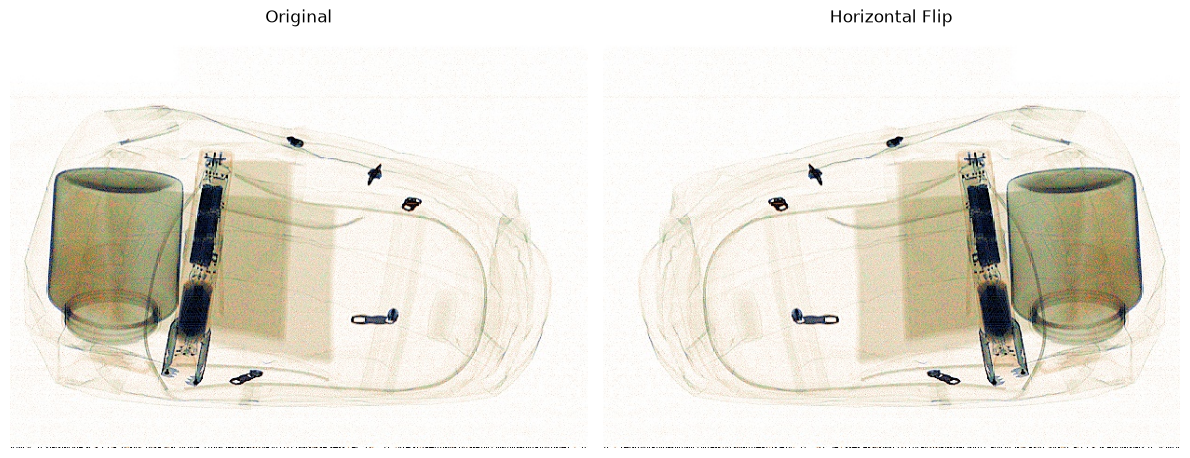

In [14]:
flipped = cv2.flip(image, 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(flipped)
plt.title("Horizontal Flip")
plt.axis("off")

plt.tight_layout()
plt.show()